<a href="https://colab.research.google.com/github/NelvaAdalit/-INTELIGENCIA-ARTIFICIAL-I-/blob/main/7LAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Estudiante: **Mora Barrionuevo Nelva Adalit**

In [3]:
from google.colab import drive
import zipfile
import os

# 1. Conectamos a tu Google Drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
from google.colab import drive
import zipfile
import os

# 1. Conectamos a tu Google Drive
drive.mount('/content/gdrive')

# 2. Definimos las rutas
ruta_zip = '/content/gdrive/MyDrive/SIS420IA/fruits-360-100x100-main.zip'
ruta_destino = '/content/dataset_frutas' # Lo extraemos en Colab para que sea rapidísimo y no se pierdan datos

# 3. Descomprimimos
print("Descomprimiendo el dataset original completo... (esto tomará un par de minutos)")
with zipfile.ZipFile(ruta_zip, 'r') as zip_ref:
    zip_ref.extractall(ruta_destino)

print("¡Descomprimido con éxito!")

# 4. Verificamos que la carpeta principal esté ahí
print("Contenido en la carpeta de destino:", os.listdir(ruta_destino))

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Descomprimiendo el dataset original completo... (esto tomará un par de minutos)
¡Descomprimido con éxito!
Contenido en la carpeta de destino: ['fruits-360-100x100-main']


In [ ]:
from google.colab import drive
import os
import numpy as np
from PIL import Image

# 1. Conexión a Google Drive
drive.mount('/content/gdrive')

# 2. Definición de rutas directas (según el consejo del auxiliar)
# Cambiamos la ruta para que apunte directamente a la carpeta en tu Drive
ruta_carpetas = '/content/gdrive/MyDrive/SIS420IA/Dataset_15_Familias'

# Verificación de familias
if os.path.exists(ruta_carpetas):
    carpetas_clases = sorted(os.listdir(ruta_carpetas))
    print(f"✅ Carpeta encontrada. Familias detectadas ({len(carpetas_clases)}):")
    print(carpetas_clases)
else:
    print("❌ Error: No se encontró la carpeta en la ruta especificada.")

In [ ]:
# 3. Conversión de imágenes a matrices matemáticas
print("🔄 Procesando y normalizando imágenes... (esto puede tardar unos minutos)")

X_list = []
y_list = []

# Asignación de ID numérico automático por familia
label_to_id = {familia: i for i, familia in enumerate(carpetas_clases)}

for nombre_clase in carpetas_clases:
    ruta_clase = os.path.join(ruta_carpetas, nombre_clase)
    if not os.path.isdir(ruta_clase): continue

    for archivo in os.listdir(ruta_clase):
        if archivo.lower().endswith(('.jpg', '.jpeg', '.png')):
            ruta_img = os.path.join(ruta_clase, archivo)

            # Procesamiento: 100x100, RGB, aplanado y normalización (0 a 1)
            # Cada imagen se convierte en un vector de 30,000 dimensiones (100x100x3)
            img = Image.open(ruta_img).convert('RGB')
            img_vector = np.array(img).flatten() / 255.0

            X_list.append(img_vector)
            y_list.append(label_to_id[nombre_clase])

# Conversión a formato NumPy
X_full = np.array(X_list, dtype=np.float32)
y_full = np.array(y_list, dtype=np.int64)

# 4. Guardado del archivo .npz oficial en Drive
ruta_npz = '/content/gdrive/MyDrive/SIS420IA/dataset_frutas_procesado.npz'
np.savez_compressed(ruta_npz, X=X_full, y=y_full)

print(f"\n✅ ¡Dataset procesado y guardado en: {ruta_npz}")
print(f"📊 Forma de X (Características): {X_full.shape}")
print(f"📊 Forma de y (Etiquetas): {y_full.shape}")

**DESDE AQUI TRABAJO**

**SEMISUPERVISADO**

In [4]:
from sklearn.model_selection import train_test_split
import numpy as np

# 1. Cargamos TU archivo procesado (no el de bloodmnist)
data = np.load("/content/gdrive/MyDrive/SIS420IA/dataset_frutas_procesado.npz")

X_full = data["X"]
y_full = data["y"]

# 2. Dividimos los datos directamente (80% para entrenar, 20% para testear)
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (11580, 30000)
y_train shape: (11580,)
X_test shape: (2895, 30000)
y_test shape: (2895,)


DEFINICION DE K //PUEDO MODIFICAR SI LO NECESITO

In [8]:
from sklearn.cluster import KMeans
k = 15
print(f"Buscando {k} frutas representativas...")
kmeans = KMeans(n_clusters=k, random_state=42)
X_fruits_dist = kmeans.fit_transform(X_train)

print("Distancias calculadas. Forma:", X_fruits_dist.shape)

Buscando 15 frutas representativas...
Distancias calculadas. Forma: (11580, 15)


In [9]:
idxs = np.argmin(X_fruits_dist, axis=0)
X_representative_fruits = X_train[idxs]

Mostrando las 15 frutas más representativas:


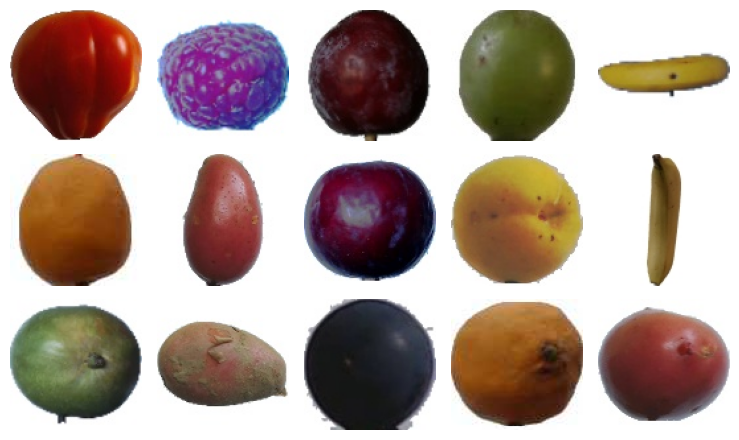

In [10]:
import matplotlib.pyplot as plt
import math

# Lógica dinámica: calcula la cuadrícula perfecta según el valor de 'k' que elijas
columnas = 10 if k >= 20 else 5
filas = math.ceil(k / columnas)

print(f"Mostrando las {k} frutas más representativas:")
plt.figure(figsize=(columnas * 1.5, filas * 1.5))

for index, X_representative_fruit in enumerate(X_representative_fruits):
    plt.subplot(filas, columnas, index + 1)
    # Adaptado a 100x100
    plt.imshow(X_representative_fruit.reshape(100, 100, 3))
    plt.axis('off')

plt.tight_layout()
plt.show()

gardo de similitud , el patron , la etiueta mas representativa

In [11]:
y_representative_fruits = y_train[idxs]

In [12]:
from sklearn.linear_model import LogisticRegression

log_reg2 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg2.fit(X_representative_fruits, y_representative_fruits)
print(f"Precisión con las {k} frutas representativas:", log_reg2.score(X_test, y_test))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 6.67 s, sys: 6.11 ms, total: 6.68 s
Wall time: 3.44 s
Precisión con las 15 frutas representativas: 0.4003454231433506


In [13]:
idxs_azar = np.random.choice(len(X_train), k, replace=False)
log_reg = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)

%time log_reg.fit(X_train[idxs_azar], y_train[idxs_azar])
print(f"Precisión con {k} frutas al azar:", log_reg.score(X_test, y_test))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 7.23 s, sys: 6.95 ms, total: 7.24 s
Wall time: 4.53 s
Precisión con 15 frutas al azar: 0.28082901554404144


In [14]:
# 1. Propagamos
y_train_propagated = np.empty(len(X_train), dtype=np.int64)
for i in range(k):

    y_train_propagated[kmeans.labels_==i] = y_representative_fruits[i]

# 2. Entrenamos
log_reg3 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
%time log_reg3.fit(X_train[:1000], y_train_propagated[:1000])
print(f"Precisión final con Propagación de Etiquetas (k={k}):", log_reg3.score(X_test, y_test))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 1min 8s, sys: 118 ms, total: 1min 8s
Wall time: 46 s
Precisión final con Propagación de Etiquetas (k=15): 0.42694300518134715


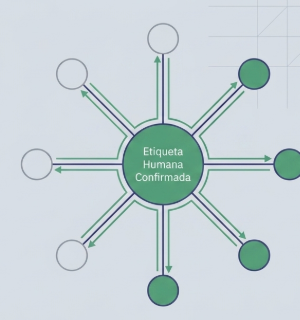

**ACTIVO**

In [15]:
probas = log_reg3.predict_proba(X_train[:1000])

labels_ixs = np.argmax(probas, axis=1)
labels = np.array([proba[ix] for proba, ix in zip(probas, labels_ixs)])
sorted_ixs = np.argsort(labels)

# Mostramos el nivel de confianza de las 10 peores (las que más lo confunden)
labels[sorted_ixs[:10]]

array([0.84417097, 0.87346462, 0.89309949, 0.90571846, 0.90761228,
       0.90840176, 0.92350043, 0.92834907, 0.93067647, 0.93526392])

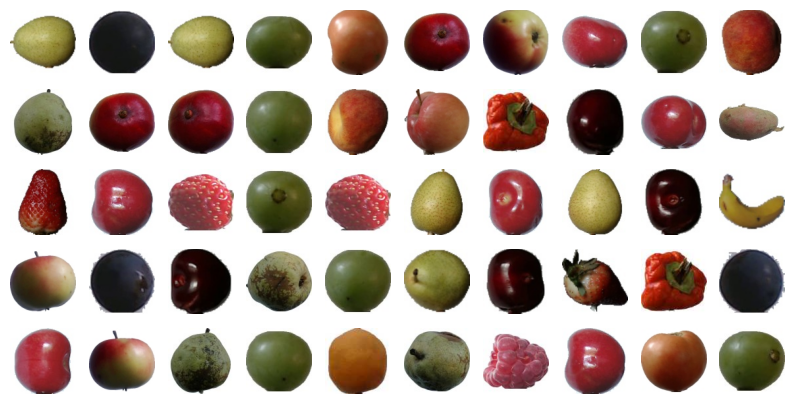

In [16]:
import matplotlib.pyplot as plt

k = 50 # Definimos k (por ejemplo, 50 imágenes a revisar)
X_lowest = X_train[:1000][sorted_ixs[:k]]

plt.figure(figsize=(10, 5))
for index, img in enumerate(X_lowest):
    plt.subplot(k // 10, 10, index + 1)

    plt.imshow(img.reshape(100, 100, 3))
    plt.axis('off')
plt.show()

In [17]:

y_lowest = y_train[:1000][sorted_ixs[:k]]
y_lowest

array([ 7,  3,  7,  3, 13,  4,  0,  2,  3,  6,  7,  4,  4,  3,  6,  0,  8,
        2,  2, 10, 12,  2, 12,  3, 12,  7,  2,  7,  2,  1,  0,  3,  2,  7,
        3,  7,  2, 12,  8,  3,  2,  0,  7,  3,  5,  7, 11,  2, 13,  3])

In [18]:

y_train2 = y_train_propagated[:1000].copy()


y_train2[sorted_ixs[:k]] = y_lowest

In [19]:
from sklearn.linear_model import LogisticRegression


log_reg5 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)


%time log_reg5.fit(X_train[:1000], y_train2)

score = log_reg5.score(X_test, y_test)
print(f"Precisión final tras aprendizaje activo: {score * 100:.2f}%")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: user 1min 54s, sys: 196 ms, total: 1min 54s
Wall time: 1min 10s
Precisión final tras aprendizaje activo: 46.98%
